Ejemplo del libro de Ciaburro: https://github.com/PacktPublishing/Hands-On-Simulation-Modeling-with-Python-Second-Edition

In [2]:
import random
import statistics 
import matplotlib.pyplot as plt

El estadístico a calcular es el Coeficiente de Variación (CV). Se calcula como el cociente entre la desviación estándar y el vlaor medio.

In [5]:
random.seed(5)

PopData = list()

for i in range(100):
    DataElem = 10 * random.random()
    PopData.append(DataElem)
# La población es una distribuciónn uniforme entre 0 y 10
# La muestra son los 100 datos tomados de esa población
# La llamamos PopData para no cambiar el código original, pero en realidad es una MUESTRA de la población

def CVCalc(Dat):
    CVCalc = statistics.stdev(Dat)/statistics.mean(Dat) 
    return CVCalc

CVPopData = CVCalc(PopData)
print("CV de la muestra original = ", CVPopData)



CV de la muestra original =  0.6569398125747403


In [11]:
N = len(PopData)
JackVal = list()
PseudoVal = list()
for i in range(N-1):
    JackVal.append(0)
for i in range(N):
    PseudoVal.append(0)

for i in range(N):
    for j in range(N):
        if(j < i): 
            JackVal[j] = PopData[j]
        else:
            if(j > i):
                JackVal[j-1]= PopData[j]
    PseudoVal[i] = N*CVCalc(PopData)-(N-1)*CVCalc(JackVal)

print("Estadísticos insesgados con Jackknife = \n", PseudoVal)
print("Valor del estadístico insesgado con Jackknife = ", statistics.mean(PseudoVal))
print("Valor del estadístico para la muestra original = ", CVPopData)


Estadísticos insesgados con Jackknife = 
 [0.20820431302664133, 0.1876888049363714, 0.2075774555257226, 0.357301347586926, 0.18731747673194832, 0.328541964794141, 1.6242099366703258, 0.37112707697831127, 0.3586590219915138, 0.196095598279328, 0.30083048466300966, 1.2909925821937378, 0.3659121900720379, 0.8528908561703616, 0.2709666128797181, 0.24242729226419613, 1.692035896758881, 0.9413992923530969, 0.7616460485344447, 0.32050677768241087, 0.19435854017804388, 1.126130195410397, 0.20864957790033145, 1.198522369971272, 0.2112727448869265, 1.2416765650680759, 1.7413957538233404, 0.2675588903246222, 0.9638022618660642, 0.945222046583396, 0.4222982583299739, 0.2685977321959854, 0.7357034362179036, 0.3869322464269942, 0.2757470887996192, 0.1876666693875677, 0.9783797458362926, 0.35510463215833, 0.18560310212036768, 0.39525577041969484, 0.2922366053690837, 0.7112198932371996, 0.5639315907233851, 1.1045953397780437, 1.1741325987224087, 1.4758247867549414, 0.7046799214234198, 0.22023635504970

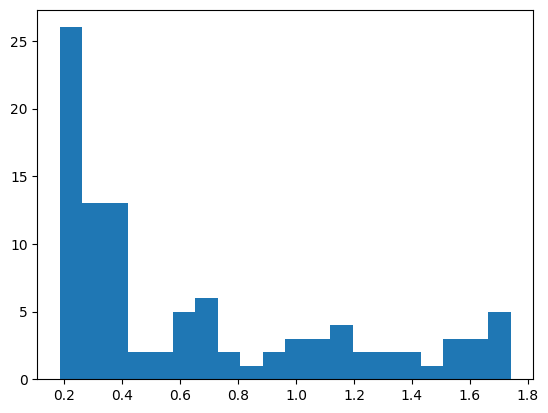

0.6545985339842985
0.24359292994440956
0.0024359292994440957


In [4]:
plt.hist(PseudoVal,bins=20)
plt.show()

MeanPseudoVal=statistics.mean(PseudoVal)
print(MeanPseudoVal)
VariancePseudoVal=statistics.variance(PseudoVal)
print(VariancePseudoVal)
VarJack = statistics.variance(PseudoVal)/N
print(VarJack)